In [1]:
# Importing Libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np

In [2]:
# Reading the file
import pandas as pd
data = pd.read_csv(r"C:\Users\Disha\IISER - B Summer Internship\US Soybeans Futures Historical Data.csv")

In [3]:
# Converting "Price", "Open", "High", "Low", "Vol." columns to float datatype
data['Price'] = data['Price'].str.replace(',', '').astype(float)
data['Open'] = data['Open'].str.replace(',', '').astype(float)
data['High'] = data['High'].str.replace(',', '').astype(float)
data['Low'] = data['Low'].str.replace(',', '').astype(float)
data['Vol.'] = data['Vol.'].str.replace('K', '').astype(float) * 1000.

In [4]:
# fill missing values with mean of the column
data = data.fillna(data.mean())

# Check for null values in each column again
null_counts = data.isnull().sum()

# Print the number of null values in each column
print(null_counts)

Date        0
Price       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64


In [5]:
# Drop a column from the dataset
data = data.drop('Date', axis=1)

# Drop a column from the dataset
data = data.drop('Change %', axis=1)

# Show the updated dataset
print(data.head())

     Price     Open     High      Low      Vol.
0  1524.00  1495.75  1537.50  1485.00  321320.0
1  1479.00  1470.00  1489.00  1460.00  374100.0
2  1480.00  1482.12  1487.62  1457.75   69330.0
3  1483.75  1440.50  1492.75  1435.25  496710.0
4  1438.50  1428.25  1478.50  1424.00  420750.0


In [6]:
# extract features and target
X = data[['Open', 'High', 'Low']]
y = data['Price']

In [7]:
# reshape the target variable into a 2D array
y = y.values.reshape(-1, 1)

In [8]:
# split the data into training and test sets
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.02, random_state=42)

In [9]:
# create a linear regression model
LinReg = LinearRegression()

In [10]:
# fit the model to the training data
LinReg.fit(train_X, train_y)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [11]:
# make predictions on the test data
pred = LinReg.predict(test_X)

In [12]:
# Calculate R-squared
score = LinReg.score(test_X, test_y)
print("R^2 Score:", score)

R^2 Score: 0.9957215781405534


In [13]:
# Evaluate the model's performance
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(test_y, pred))
print("Root Mean Squared Error: ", rmse)

Root Mean Squared Error:  20.29792761646584


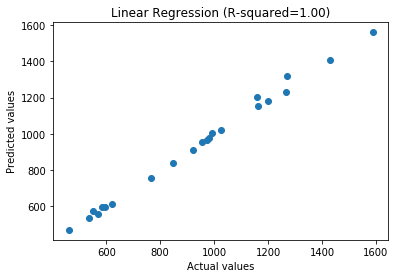

In [14]:
# Plot actual vs predicted values
import matplotlib.pyplot as plt

plt.scatter(test_y, pred)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title(f"Linear Regression (R-squared={score:.2f})")
plt.show()